# **KLUE RE EDA**

## **0. EDA 수행 개요**

**1. `데이터 로드 및 기본 정보 확인`**

**2. `결측치 확인`**
   - → 결측 데이터 없음 → 별도 제거 없이 전체 데이터 유지

**3. `중복 데이터 확인`**
   - 완전 중복과 entity pair 기준 중복 여부 확인
   - 일부 중복 데이터 존재 확인 (2가지 기준)
   - → **`EDA Insight 1`** 중복 데이터 제거 여부 성능 비교 실험 필요

**4. `데이터 분포 및 관계 특성 분석`**
   - label 분포 확인
   - subject-object type 조합과 label 관계 분석 -> **`EDA Insight 2`** Typed Marker 실험 필요성 도출
   - label 분포가 `no_relation`에 편향되어 있으나, sbj-object 기준에서는 비교적 편향이 완화됨

     ->  **`EDA Insight 3`** `{label}-{subject_type}-{object_type}` 기반 Data Split 실험 수행

## **1. 데이터 로드 및 기본 정보 확인**

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src' / 'data_loader.py').exists() and (path / 'configs').exists():
            return path
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. notebooks 폴더 또는 프로젝트 루트에서 실행해 주세요.')

ROOT = find_project_root()
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

from data_loader import DEFAULT_RAW_DATA_DIR, HF_TEST_SPLIT, load_saved_klue_re

dataset, label_names, label2id, id2label = load_saved_klue_re(DEFAULT_RAW_DATA_DIR)
train_df = dataset['train'].to_pandas()
test_df = dataset[HF_TEST_SPLIT].to_pandas()

display(pd.DataFrame({
    'split': ['train', 'test'],
    'num_rows': [len(train_df), len(test_df)],
    'num_columns': [train_df.shape[1], test_df.shape[1]],
}))
display(train_df.head())

c:\Users\gyr\anaconda3\envs\klue-re\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,split,num_rows,num_columns
0,train,32470,6
1,test,7765,6


,guid,sentence,subject_entity,object_entity,label,source
0,klue-re-v1_train_00000,〈Something〉는 조지 해리슨이 쓰고 비틀즈가 1969년 앨범 《Abbey R...,"{'word': '비틀즈', 'start_idx': 24, 'end_idx': 26...","{'word': '조지 해리슨', 'start_idx': 13, 'end_idx':...",0,wikipedia
1,klue-re-v1_train_00001,호남이 기반인 바른미래당·대안신당·민주평화당이 우여곡절 끝에 합당해 민생당(가칭)으...,"{'word': '민주평화당', 'start_idx': 19, 'end_idx': ...","{'word': '대안신당', 'start_idx': 14, 'end_idx': 1...",0,wikitree
2,klue-re-v1_train_00002,K리그2에서 성적 1위를 달리고 있는 광주FC는 지난 26일 한국프로축구연맹으로부터...,"{'word': '광주FC', 'start_idx': 21, 'end_idx': 2...","{'word': '한국프로축구연맹', 'start_idx': 34, 'end_idx...",5,wikitree
3,klue-re-v1_train_00003,균일가 생활용품점 (주)아성다이소(대표 박정부)는 코로나19 바이러스로 어려움을 겪...,"{'word': '아성다이소', 'start_idx': 13, 'end_idx': ...","{'word': '박정부', 'start_idx': 22, 'end_idx': 24...",10,wikitree
4,klue-re-v1_train_00004,1967년 프로 야구 드래프트 1순위로 요미우리 자이언츠에게 입단하면서 등번호는 8...,"{'word': '요미우리 자이언츠', 'start_idx': 22, 'end_id...","{'word': '1967', 'start_idx': 0, 'end_idx': 3,...",0,wikipedia


In [2]:
print('columns:', train_df.columns.tolist())
print('num_labels:', len(label_names))

columns: ['guid', 'sentence', 'subject_entity', 'object_entity', 'label', 'source']
num_labels: 30


## **2. 결측치 확인**
-> 없음

In [3]:
missing_summary = pd.concat(
    {
        'train': train_df.isna().sum(),
        'test': test_df.isna().sum(),
    },
    axis=1,
)
missing_summary['total'] = missing_summary.sum(axis=1)
display(missing_summary)

,train,test,total
guid,0,0,0
sentence,0,0,0
subject_entity,0,0,0
object_entity,0,0,0
label,0,0,0
source,0,0,0


## **3. 중복 데이터 확인**

- **완전 중복(0.26%)**: `sentence + subject_entity + object_entity + label`
- **Entity Pair 중복(0.29%)**: `sentence + subject_entity + object_entity`

- 완전 중복 데이터는 동일 학습 샘플이 반복되어 특정 패턴에 과적합될 가능성이 있음
- 다만 **전체 데이터 대비 중복 비율이 낮고, 동일 샘플이 최대 2개씩만 반복되는 형태로 나타나 데이터 편향 영향이 크지 않을 것으로 판단**



- **`EDA Insight 1`** 중복 제거 여부는 이후 성능 개선 단계에서 제거 여부 실험 성능 비교 수행

In [4]:
# subject_entity / object_entity를 비교 가능한 문자열로 변환
train_check = train_df.copy()
test_check = test_df.copy()

train_check["subject_key"] = train_check["subject_entity"].astype(str)
train_check["object_key"] = train_check["object_entity"].astype(str)

test_check["subject_key"] = test_check["subject_entity"].astype(str)
test_check["object_key"] = test_check["object_entity"].astype(str)

# 중복 기준
complete_key = ["sentence","subject_key","object_key","label"]
pair_key = ["sentence","subject_key","object_key"]

# train
train_complete = train_check[train_check.duplicated(subset=complete_key, keep=False,)]
train_pair = train_check[train_check.duplicated(subset=pair_key,keep=False,)]

# test
valid_complete = test_check[test_check.duplicated(subset=complete_key,keep=False,)]
valid_pair = test_check[test_check.duplicated(subset=pair_key,keep=False,)]

# 결과 출력
print("[train]")
print(f"complete duplicate: {len(train_complete)} ({len(train_complete)/len(train_df)*100}%)")
print(f"entity pair duplicate: {len(train_pair)} ({len(train_pair)/len(train_df)*100}%)")
# print("entity pair duplicate:", len(train_pair))

print("\n[test]")
print("complete duplicate:", len(valid_complete))
print("entity pair duplicate:", len(valid_pair))


[train]
complete duplicate: 84 (0.2587003387742532%)
entity pair duplicate: 93 (0.2864182322143517%)

[test]
complete duplicate: 0
entity pair duplicate: 0


In [5]:
# complete duplicate: 2개쌍 / 3개쌍 / ... 확인
print("[train] complete duplicate group size")

display(
    train_check
    .groupby(complete_key)
    .size()
    .reset_index(name="duplicate_size")
    .query("duplicate_size > 1")["duplicate_size"]
    .value_counts()
    .sort_index()
    .rename_axis("pair_size")
    .reset_index(name="num_groups")
)

print("\n[test] complete duplicate group size")

display(
    test_check
    .groupby(complete_key)
    .size()
    .reset_index(name="duplicate_size")
    .query("duplicate_size > 1")["duplicate_size"]
    .value_counts()
    .sort_index()
    .rename_axis("pair_size")
    .reset_index(name="num_groups")
)

print("\n[train] entity pair duplicate group size")

display(
    train_check
    .groupby(pair_key)
    .size()
    .reset_index(name="duplicate_size")
    .query("duplicate_size > 1")["duplicate_size"]
    .value_counts()
    .sort_index()
    .rename_axis("pair_size")
    .reset_index(name="num_groups")
)

[train] complete duplicate group size


,pair_size,num_groups
0,2,42



[test] complete duplicate group size


,pair_size,num_groups



[train] entity pair duplicate group size


,pair_size,num_groups
0,2,45
1,3,1


## **4. 데이터 분포 확인**

### **4.1 Label 데이터 분포**
- label 분포가 no-relation에 편향된 것 확인 (전체 데이터의 약 30%)

,label,count,ratio
0,no_relation,9534,0.293625
1,org:top_members/employees,4284,0.131937
2,per:employee_of,3573,0.110040
3,per:title,2103,0.064767
4,org:member_of,1866,0.057468
5,org:alternate_names,1320,0.040653
6,per:origin,1234,0.038004
7,org:place_of_headquarters,1195,0.036803
8,per:date_of_birth,1130,0.034801
9,per:alternate_names,1001,0.030828


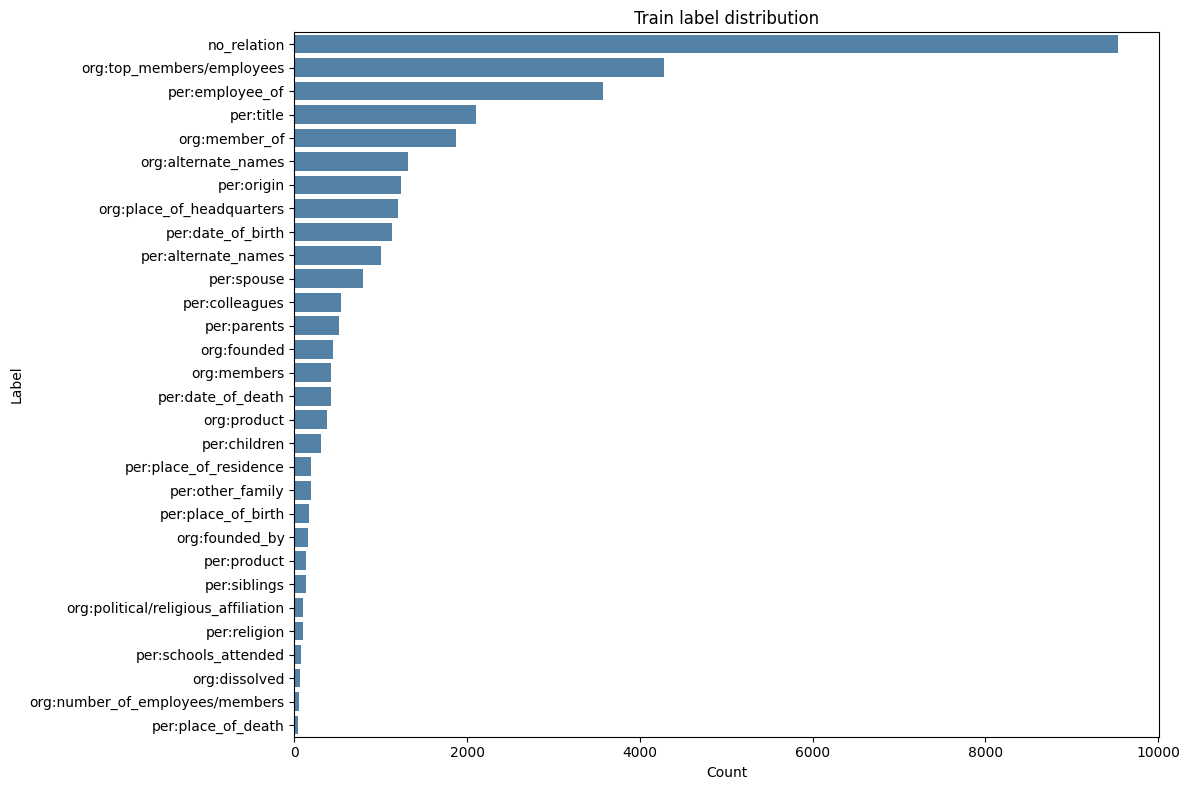

In [6]:
eda_train = train_df.copy()
eda_train['label_name'] = eda_train['label'].map(id2label)

label_counts = eda_train['label_name'].value_counts().rename_axis('label').reset_index(name='count')
label_counts['ratio'] = label_counts['count'] / len(eda_train)
display(label_counts)

plt.figure(figsize=(12, 8))
sns.barplot(data=label_counts, y='label', x='count', color='steelblue')
plt.title('Train label distribution')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

### **4-2. subject-object type 조합과 label 간 빈도 히트맵**

- 일부 label은 특정 subject-object type 조합에서 집중적으로 나타남
  - entity type 정보가 관계 label 예측에 유용한 단서로 활용될 수 있음을 확인
  - → subject/object 위치 정보뿐 아니라 entity type 정보를 함께 제공하는 `typed marker` 기반 입력 방식 실험 수행
  - **`EDA Insight 2`** Typed Marker 실험 필요성 도출

- `no_relation`은 특정 조합에 편중되지 않고 다양한 subject-object type 조합에 넓게 분포함
  - 단순 label 비율만 유지할 경우 train/val 간 entity type 조합 분포 차이가 발생할 가능성이 있음
  - → train/val split 시 `{label}-{subject_type}-{object_type}` 정보를 함께 고려하는 stratified split 방식 성능 비교 실험 수행
  - **`EDA Insight 3`** `{label}-{subject_type}-{object_type}` 기반 Data Split 실험 수행

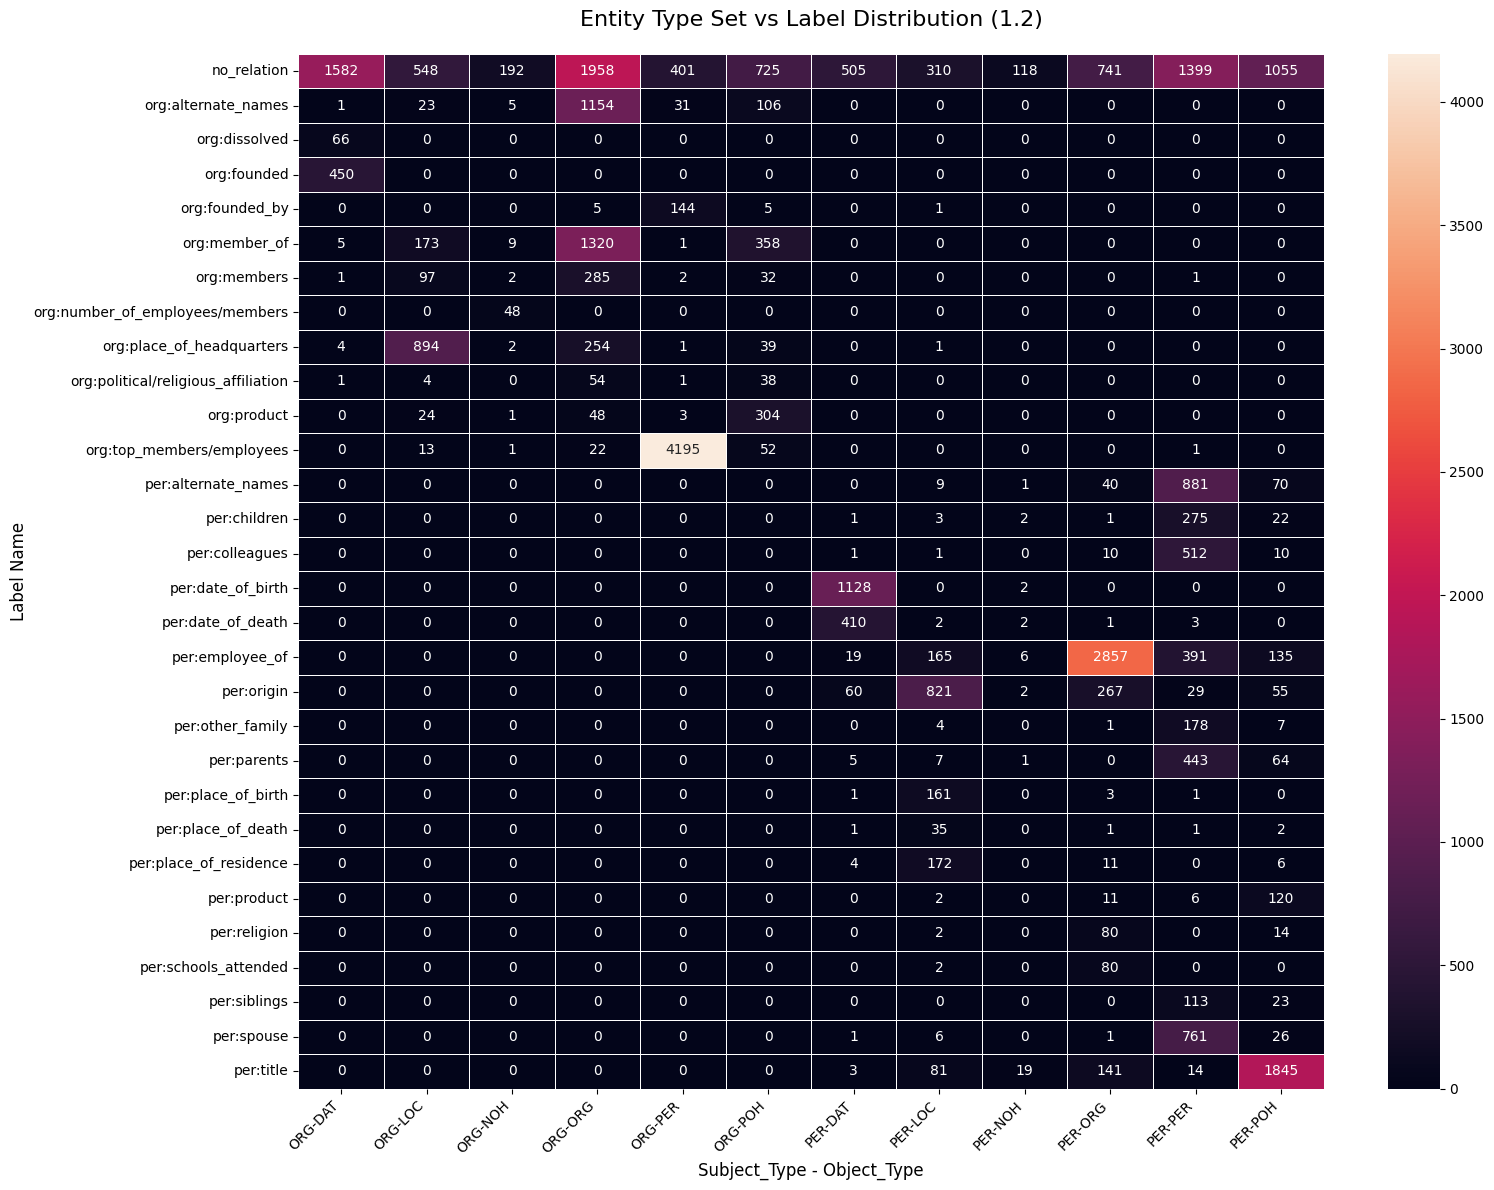

In [7]:
combo_df = eda_train.copy()
combo_df['label_name'] = combo_df['label'].map(id2label)
combo_df['subject_type'] = combo_df['subject_entity'].map(lambda x: x['type'])
combo_df['object_type'] = combo_df['object_entity'].map(lambda x: x['type'])
combo_df['type_set'] = combo_df['subject_type'] + '-' + combo_df['object_type']

cross_tab = pd.crosstab(
    index=combo_df['label_name'], 
    columns=combo_df['type_set'], 
    margins=True,          # 오른쪽(All)과 아래쪽(All) 합계 추가
    margins_name='All'
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cross_tab.drop('All', axis=0).drop('All', axis=1), 
    annot=True,          # 셀 내부에 숫자 표시
    fmt="d",             # 정수 형태 포맷
    linewidths=.5
)

plt.title('Entity Type Set vs Label Distribution (1.2)', fontsize=16, pad=20)
plt.xlabel('Subject_Type - Object_Type', fontsize=12)
plt.ylabel('Label Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()